In [24]:
pip install transformers torch torchvision pillow matplotlib requests

Note: you may need to restart the kernel to use updated packages.


In [25]:
import torch
import requests
from PIL import Image
import matplotlib.pyplot as plt

from transformers import ViTImageProcessor
from transformers import ViTForImageClassification

In [26]:
import torch

print(torch.__version__)

2.13.0+cpu


In [27]:
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

print("Processor Loaded")

Processor Loaded


In [28]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224"
)

print("Model Loaded")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4036.89it/s]

Model Loaded


In [29]:
import requests

url = "https://huggingface.co"

response = requests.get(url)

print(response.status_code)

200


In [30]:
import os
print(os.getcwd())

C:\Users\sai maha\DEEP LEARNING TASKS


In [31]:
import os
print(os.getcwd())

C:\Users\sai maha\DEEP LEARNING TASKS


In [32]:
import os
print(os.getcwd())


C:\Users\sai maha\DEEP LEARNING TASKS


In [33]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\sai maha\DEEP LEARNING TASKS
[' DL Task 3.ipynb', '.ipynb_checkpoints', 'bird.jpeg', 'car.jpeg', 'cat.jpeg', 'Contacts', 'Deep Learning basics -Copy1.ipynb', 'Deep Learning basics .ipynb', 'Deep learning task 1 .ipynb', 'DL Task 2.ipynb', 'DL Task 4.ipynb', 'DL Task 4.txt', 'dog.jpeg', 'flower.jpeg']


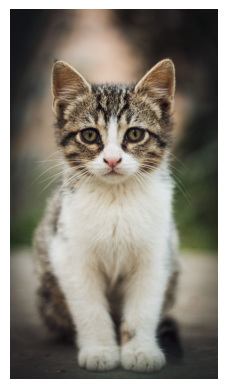

In [34]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("cat.jpeg")

plt.imshow(image)
plt.axis("off")
plt.show()

In [35]:
from transformers import ViTImageProcessor, ViTForImageClassification

# Load pretrained ViT model and processor
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

print("Model loaded successfully")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4212.06it/s]

Model loaded successfully


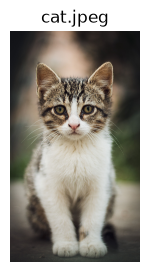

Image: cat.jpeg
Predicted Class: Egyptian cat
Confidence Score: 52.4 %
---------------------------


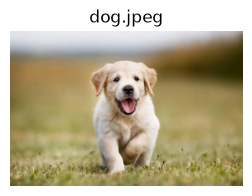

Image: dog.jpeg
Predicted Class: Labrador retriever
Confidence Score: 96.68 %
---------------------------


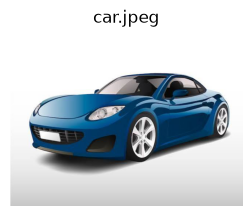

Image: car.jpeg
Predicted Class: sports car, sport car
Confidence Score: 92.17 %
---------------------------


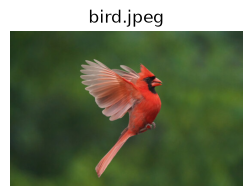

Image: bird.jpeg
Predicted Class: house finch, linnet, Carpodacus mexicanus
Confidence Score: 24.97 %
---------------------------


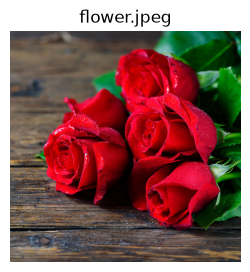

Image: flower.jpeg
Predicted Class: vase
Confidence Score: 36.97 %
---------------------------


In [36]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

# List of image names
image_files = [
    "cat.jpeg",
    "dog.jpeg",
    "car.jpeg",
    "bird.jpeg",
    "flower.jpeg"
]

# Predict each image
for img_name in image_files:
    
    # Load image
    image = Image.open(img_name).convert("RGB")
    
    # Display image
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.axis("off")
    plt.title(img_name)
    plt.show()
    
    # Process image
    inputs = processor(images=image, return_tensors="pt")
    
    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get class and confidence
    predicted_class = outputs.logits.argmax(-1).item()
    label = model.config.id2label[predicted_class]
    
    confidence = torch.nn.functional.softmax(
        outputs.logits, dim=1
    )[0][predicted_class].item()
    
    print("Image:", img_name)
    print("Predicted Class:", label)
    print("Confidence Score:", round(confidence*100,2), "%")
    print("---------------------------")